# Análise Estrutural e Estatística: FailureSensorIQ e FinQA

**Objetivo:** Realizar análise estrutural e estatística das bases FailureSensorIQ e FinQA, identificando transformações e padronizações necessárias para o processo de Fine-Tuning.

**Datasets:**
- **FailureSensorIQ**: Formato JSONL, dados categóricos e textuais com perguntas de múltipla escolha sobre falhas e sensores
- **FinQA**: Formato JSON, dados textuais e tabulares com raciocínio numérico e operações financeiras


In [1]:
# Imports e configurações
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

print("Análise Estrutural e Estatística: FailureSensorIQ e FinQA")
print("=" * 60)


Análise Estrutural e Estatística: FailureSensorIQ e FinQA


## 1. Carregamento e Inspeção Estrutural dos Datasets


In [2]:
# Carregamento do dataset FinQA
try:
    with open('FinQA/dataset/train.json', 'r', encoding='utf-8') as f:
        dataset_finqa = pd.DataFrame(json.load(f))
    print(f"FinQA carregado: {len(dataset_finqa)} exemplos")
    print(f"Colunas FinQA: {list(dataset_finqa.columns)}")
except FileNotFoundError:
    print("Arquivo FinQA não encontrado")
    dataset_finqa = pd.DataFrame()

# Carregamento do dataset FailureSensorIQ
try:
    with open('FailureSensorIQ_unificado_instruct.jsonl', 'r', encoding='utf-8') as f:
        data_failure = []
        for line in f:
            data_failure.append(json.loads(line.strip()))
    dataset_failure = pd.DataFrame(data_failure)
    print(f"FailureSensorIQ carregado: {len(dataset_failure)} exemplos")
    print(f"Colunas FailureSensorIQ: {list(dataset_failure.columns)}")
except FileNotFoundError:
    print("Arquivo FailureSensorIQ não encontrado")
    dataset_failure = pd.DataFrame()


FinQA carregado: 6251 exemplos
Colunas FinQA: ['pre_text', 'post_text', 'filename', 'table_ori', 'table', 'qa', 'id', 'table_retrieved', 'text_retrieved', 'table_retrieved_all', 'text_retrieved_all']
FailureSensorIQ carregado: 8296 exemplos
Colunas FailureSensorIQ: ['prompt', 'resposta', 'question_type', 'asset_name']


### 1.1 Estrutura do Dataset FinQA


In [3]:
if not dataset_finqa.empty:
    print("ESTRUTURA DO DATASET FINQA")
    print("=" * 40)
    print(f"Dimensões: {dataset_finqa.shape}")
    print(f"Colunas: {list(dataset_finqa.columns)}")
    
    print("\nTipos de dados:")
    for col in dataset_finqa.columns:
        print(f"  {col}: {dataset_finqa[col].dtype}")
    
    print("\nValores nulos:")
    null_counts = dataset_finqa.isnull().sum()
    for col, count in null_counts.items():
        if count > 0:
            print(f"  {col}: {count} ({count/len(dataset_finqa)*100:.1f}%)")
    
    print("\nInspeção de tipos de dados nas colunas:")
    if len(dataset_finqa) > 0:
        exemplo = dataset_finqa.iloc[0]
        for col in dataset_finqa.columns:
            valor = exemplo[col]
            tipo_valor = type(valor).__name__
            if hasattr(valor, 'shape'):  # numpy array
                print(f"  {col}: {tipo_valor} com shape {valor.shape}")
            elif isinstance(valor, (list, tuple)):
                print(f"  {col}: {tipo_valor} com {len(valor)} elementos")
            else:
                print(f"  {col}: {tipo_valor}")
    
    print("\nExemplo de entrada:")
    if len(dataset_finqa) > 0:
        exemplo = dataset_finqa.iloc[0]
        # Verificar quais colunas existem antes de tentar acessá-las
        colunas_exemplo = [col for col in ['question', 'answer', 'program', 'table'] if col in exemplo]
        for col in colunas_exemplo:
            valor = exemplo[col]
            if hasattr(valor, 'shape'):  # numpy array
                print(f"  {col}: array com shape {valor.shape}")
            elif isinstance(valor, (list, tuple)) and len(valor) > 0:
                print(f"  {col}: {type(valor).__name__} com {len(valor)} elementos - primeiro: {str(valor[0])[:100]}...")
            else:
                print(f"  {col}: {str(valor)[:200]}...")
else:
    print("Dataset FinQA não disponível")


ESTRUTURA DO DATASET FINQA
Dimensões: (6251, 11)
Colunas: ['pre_text', 'post_text', 'filename', 'table_ori', 'table', 'qa', 'id', 'table_retrieved', 'text_retrieved', 'table_retrieved_all', 'text_retrieved_all']

Tipos de dados:
  pre_text: object
  post_text: object
  filename: object
  table_ori: object
  table: object
  qa: object
  id: object
  table_retrieved: object
  text_retrieved: object
  table_retrieved_all: object
  text_retrieved_all: object

Valores nulos:

Inspeção de tipos de dados nas colunas:
  pre_text: list com 15 elementos
  post_text: list com 35 elementos
  filename: str
  table_ori: list com 4 elementos
  table: list com 4 elementos
  qa: dict
  id: str
  table_retrieved: list com 2 elementos
  text_retrieved: list com 3 elementos
  table_retrieved_all: list com 4 elementos
  text_retrieved_all: list com 50 elementos

Exemplo de entrada:
  table: list com 4 elementos - primeiro: ['', 'october 31 2009', 'november 1 2008']...


### 1.2 Estrutura do Dataset FailureSensorIQ


In [4]:
if not dataset_failure.empty:
    print("ESTRUTURA DO DATASET FAILURESENSORIQ")
    print("=" * 40)
    print(f"Dimensões: {dataset_failure.shape}")
    print(f"Colunas: {list(dataset_failure.columns)}")
    
    print("\nTipos de dados:")
    for col in dataset_failure.columns:
        print(f"  {col}: {dataset_failure[col].dtype}")
    
    print("\nValores nulos:")
    null_counts = dataset_failure.isnull().sum()
    for col, count in null_counts.items():
        if count > 0:
            print(f"  {col}: {count} ({count/len(dataset_failure)*100:.1f}%)")
    
    print("\nInspeção de tipos de dados nas colunas:")
    if len(dataset_failure) > 0:
        exemplo = dataset_failure.iloc[0]
        for col in dataset_failure.columns:
            valor = exemplo[col]
            tipo_valor = type(valor).__name__
            if hasattr(valor, 'shape'):  # numpy array
                print(f"  {col}: {tipo_valor} com shape {valor.shape}")
            elif isinstance(valor, (list, tuple)):
                print(f"  {col}: {tipo_valor} com {len(valor)} elementos")
            else:
                print(f"  {col}: {tipo_valor}")
    
    print("\nExemplo de entrada:")
    if len(dataset_failure) > 0:
        exemplo = dataset_failure.iloc[0]
        for col in ['question', 'options', 'correct']:
            if col in exemplo:
                valor = exemplo[col]
                if hasattr(valor, 'shape'):  # numpy array
                    print(f"  {col}: array com shape {valor.shape}")
                elif isinstance(valor, (list, tuple)) and len(valor) > 0:
                    print(f"  {col}: {type(valor).__name__} com {len(valor)} elementos - primeiro: {str(valor[0])[:100]}...")
                else:
                    print(f"  {col}: {str(valor)[:200]}...")
else:
    print("Dataset FailureSensorIQ não disponível")


ESTRUTURA DO DATASET FAILURESENSORIQ
Dimensões: (8296, 4)
Colunas: ['prompt', 'resposta', 'question_type', 'asset_name']

Tipos de dados:
  prompt: object
  resposta: object
  question_type: object
  asset_name: object

Valores nulos:

Inspeção de tipos de dados nas colunas:
  prompt: str
  resposta: str
  question_type: str
  asset_name: str

Exemplo de entrada:


## 3. Estatísticas Descritivas do FinQA


In [5]:
if not dataset_finqa.empty:
    print("ESTATÍSTICAS DESCRITIVAS DO FINQA")
    print("=" * 40)
    
    # Análise individual das colunas disponíveis no FinQA
    colunas_stats = []
    
    # 1. Análise da coluna 'pre_text' (listas de strings)
    if 'pre_text' in dataset_finqa.columns:
        print("Análise da coluna 'pre_text':")
        tamanhos_pre_text = []
        for idx, pre_text in enumerate(dataset_finqa['pre_text']):
            if isinstance(pre_text, list):
                total_tokens = sum(len(str(item).split()) for item in pre_text if item is not None)
                tamanhos_pre_text.append(total_tokens)
            else:
                tamanhos_pre_text.append(0)
        
        dataset_finqa['tamanho_pre_text'] = tamanhos_pre_text
        colunas_stats.append('tamanho_pre_text')
        print(f"  Média: {np.mean(tamanhos_pre_text):.2f} tokens")
        print(f"  Desvio padrão: {np.std(tamanhos_pre_text):.2f}")
        print(f"  Mínimo: {min(tamanhos_pre_text)}")
        print(f"  Máximo: {max(tamanhos_pre_text)}")
    
    # 2. Análise da coluna 'post_text' (listas de strings)
    if 'post_text' in dataset_finqa.columns:
        print("\nAnálise da coluna 'post_text':")
        tamanhos_post_text = []
        for idx, post_text in enumerate(dataset_finqa['post_text']):
            if isinstance(post_text, list):
                total_tokens = sum(len(str(item).split()) for item in post_text if item is not None)
                tamanhos_post_text.append(total_tokens)
            else:
                tamanhos_post_text.append(0)
        
        dataset_finqa['tamanho_post_text'] = tamanhos_post_text
        colunas_stats.append('tamanho_post_text')
        print(f"  Média: {np.mean(tamanhos_post_text):.2f} tokens")
        print(f"  Desvio padrão: {np.std(tamanhos_post_text):.2f}")
        print(f"  Mínimo: {min(tamanhos_post_text)}")
        print(f"  Máximo: {max(tamanhos_post_text)}")
    
    # 3. Análise da coluna 'table' (listas de listas)
    if 'table' in dataset_finqa.columns:
        print("\nAnálise da coluna 'table':")
        tamanhos_table = []
        for idx, table in enumerate(dataset_finqa['table']):
            if isinstance(table, list):
                total_tokens = 0
                for row in table:
                    if isinstance(row, list):
                        total_tokens += sum(len(str(cell).split()) for cell in row if cell is not None)
                    else:
                        total_tokens += len(str(row).split()) if row is not None else 0
                tamanhos_table.append(total_tokens)
            else:
                tamanhos_table.append(0)
        
        dataset_finqa['tamanho_table'] = tamanhos_table
        colunas_stats.append('tamanho_table')
        print(f"  Média: {np.mean(tamanhos_table):.2f} tokens")
        print(f"  Desvio padrão: {np.std(tamanhos_table):.2f}")
        print(f"  Mínimo: {min(tamanhos_table)}")
        print(f"  Máximo: {max(tamanhos_table)}")
    
    # 4. Análise da coluna 'qa' (dicionários)
    if 'qa' in dataset_finqa.columns:
        print("\nAnálise da coluna 'qa':")
        tamanhos_qa = []
        for idx, qa in enumerate(dataset_finqa['qa']):
            if isinstance(qa, dict):
                total_tokens = 0
                for key, value in qa.items():
                    if value is not None:
                        total_tokens += len(str(value).split())
                tamanhos_qa.append(total_tokens)
            else:
                tamanhos_qa.append(0)
        
        dataset_finqa['tamanho_qa'] = tamanhos_qa
        colunas_stats.append('tamanho_qa')
        print(f"  Média: {np.mean(tamanhos_qa):.2f} tokens")
        print(f"  Desvio padrão: {np.std(tamanhos_qa):.2f}")
        print(f"  Mínimo: {min(tamanhos_qa)}")
        print(f"  Máximo: {max(tamanhos_qa)}")
    
    # Resumo estatístico
    if colunas_stats:
        print("\nResumo estatístico completo:")
        print(dataset_finqa[colunas_stats].describe())
    else:
        print("\nNenhuma coluna de texto encontrada para análise estatística")
else:
    print("Dataset FinQA não disponível para análise")


ESTATÍSTICAS DESCRITIVAS DO FINQA
Análise da coluna 'pre_text':
  Média: 301.99 tokens
  Desvio padrão: 237.18
  Mínimo: 1
  Máximo: 1309

Análise da coluna 'post_text':
  Média: 329.67 tokens
  Desvio padrão: 259.62
  Mínimo: 1
  Máximo: 1489

Análise da coluna 'table':
  Média: 58.74 tokens
  Desvio padrão: 38.50
  Mínimo: 6
  Máximo: 589

Análise da coluna 'qa':
  Média: 264.63 tokens
  Desvio padrão: 102.96
  Mínimo: 81
  Máximo: 679

Resumo estatístico completo:
       tamanho_pre_text  tamanho_post_text  tamanho_table   tamanho_qa
count       6251.000000        6251.000000    6251.000000  6251.000000
mean         301.990562         329.670453      58.741001   264.626940
std          237.195771         259.637025      38.505010   102.967098
min            1.000000           1.000000       6.000000    81.000000
25%           98.000000         109.000000      34.000000   193.000000
50%          250.000000         300.000000      50.000000   243.000000
75%          473.000000        

## 4. Estatísticas Descritivas do FailureSensorIQ


In [6]:
if not dataset_failure.empty:
    print("ESTATÍSTICAS DESCRITIVAS DO FAILURESENSORIQ")
    print("=" * 40)
    
    # Análise individual das colunas disponíveis no FailureSensorIQ
    colunas_stats = []
    
    # 1. Análise da coluna 'question' (strings)
    if 'question' in dataset_failure.columns:
        print("Análise da coluna 'question':")
        tamanhos_pergunta = []
        for idx, question in enumerate(dataset_failure['question']):
            if question is not None and not pd.isna(question):
                tamanhos_pergunta.append(len(str(question).split()))
            else:
                tamanhos_pergunta.append(0)
        
        dataset_failure['tamanho_pergunta'] = tamanhos_pergunta
        colunas_stats.append('tamanho_pergunta')
        print(f"  Média: {np.mean(tamanhos_pergunta):.2f} tokens")
        print(f"  Desvio padrão: {np.std(tamanhos_pergunta):.2f}")
        print(f"  Mínimo: {min(tamanhos_pergunta)}")
        print(f"  Máximo: {max(tamanhos_pergunta)}")
    
    # 2. Análise da coluna 'options' (listas de strings)
    if 'options' in dataset_failure.columns:
        print("\nAnálise da coluna 'options':")
        num_opcoes = []
        tamanhos_opcoes = []
        for idx, options in enumerate(dataset_failure['options']):
            if isinstance(options, list):
                num_opcoes.append(len(options))
                total_tokens = sum(len(str(opt).split()) for opt in options if opt is not None)
                tamanhos_opcoes.append(total_tokens)
            else:
                num_opcoes.append(0)
                tamanhos_opcoes.append(0)
        
        dataset_failure['num_opcoes'] = num_opcoes
        dataset_failure['tamanho_opcoes'] = tamanhos_opcoes
        colunas_stats.extend(['num_opcoes', 'tamanho_opcoes'])
        print(f"  Número médio de opções: {np.mean(num_opcoes):.2f}")
        print(f"  Tamanho médio das opções: {np.mean(tamanhos_opcoes):.2f} tokens")
        print(f"  Mínimo de opções: {min(num_opcoes)}")
        print(f"  Máximo de opções: {max(num_opcoes)}")
    
    # 3. Análise da coluna 'correct' (listas de booleanos)
    if 'correct' in dataset_failure.columns:
        print("\nAnálise da coluna 'correct':")
        num_respostas_corretas = []
        for idx, correct in enumerate(dataset_failure['correct']):
            if isinstance(correct, list):
                num_respostas_corretas.append(sum(correct))
            else:
                num_respostas_corretas.append(0)
        
        dataset_failure['num_respostas_corretas'] = num_respostas_corretas
        colunas_stats.append('num_respostas_corretas')
        print(f"  Média de respostas corretas: {np.mean(num_respostas_corretas):.2f}")
        print(f"  Desvio padrão: {np.std(num_respostas_corretas):.2f}")
        print(f"  Mínimo: {min(num_respostas_corretas)}")
        print(f"  Máximo: {max(num_respostas_corretas)}")
    
    # 4. Distribuição por asset
    if 'subject' in dataset_failure.columns:
        print("\nDistribuição por asset (subject):")
        asset_counts = dataset_failure['subject'].value_counts()
        print(asset_counts)
    
    # 5. Distribuição por tipo de pergunta
    if 'text_type' in dataset_failure.columns:
        print("\nDistribuição por tipo de texto:")
        text_type_counts = dataset_failure['text_type'].value_counts()
        print(text_type_counts)
    
    # Resumo estatístico
    if colunas_stats:
        print("\nResumo estatístico completo:")
        print(dataset_failure[colunas_stats].describe())
    else:
        print("\nNenhuma coluna encontrada para análise estatística")
else:
    print("Dataset FailureSensorIQ não disponível para análise")


ESTATÍSTICAS DESCRITIVAS DO FAILURESENSORIQ

Nenhuma coluna encontrada para análise estatística


## 5. Análise de Balanceamento e Consistência


In [7]:
print("ANÁLISE DE BALANCEAMENTO E CONSISTÊNCIA")
print("=" * 40)

# Análise de balanceamento do FinQA
if not dataset_finqa.empty:
    print("\nFINQA - Balanceamento:")
    print(f"  Total de exemplos: {len(dataset_finqa)}")
    
    # Usar as colunas de tamanho já calculadas para verificar completude
    if 'tamanho_pre_text' in dataset_finqa.columns:
        pre_text_validos = sum(1 for x in dataset_finqa['tamanho_pre_text'] if x > 0)
        print(f"  Pre-text válidos: {pre_text_validos}")
    
    if 'tamanho_post_text' in dataset_finqa.columns:
        post_text_validos = sum(1 for x in dataset_finqa['tamanho_post_text'] if x > 0)
        print(f"  Post-text válidos: {post_text_validos}")
    
    if 'tamanho_table' in dataset_finqa.columns:
        table_validos = sum(1 for x in dataset_finqa['tamanho_table'] if x > 0)
        print(f"  Tabelas válidas: {table_validos}")
    
    if 'tamanho_qa' in dataset_finqa.columns:
        qa_validos = sum(1 for x in dataset_finqa['tamanho_qa'] if x > 0)
        print(f"  QA válidos: {qa_validos}")

# Análise de balanceamento do FailureSensorIQ
if not dataset_failure.empty:
    print("\nFAILURESENSORIQ - Balanceamento:")
    print(f"  Total de exemplos: {len(dataset_failure)}")
    
    # Usar as colunas de tamanho já calculadas para verificar completude
    if 'tamanho_pergunta' in dataset_failure.columns:
        question_validos = sum(1 for x in dataset_failure['tamanho_pergunta'] if x > 0)
        print(f"  Perguntas válidas: {question_validos}")
    
    if 'num_opcoes' in dataset_failure.columns:
        options_validos = sum(1 for x in dataset_failure['num_opcoes'] if x > 0)
        print(f"  Opções válidas: {options_validos}")
    
    if 'num_respostas_corretas' in dataset_failure.columns:
        correct_validos = sum(1 for x in dataset_failure['num_respostas_corretas'] if x > 0)
        print(f"  Respostas corretas válidas: {correct_validos}")
    
    # Análise de distribuição de respostas corretas
    if 'num_respostas_corretas' in dataset_failure.columns:
        print("\nDistribuição de respostas corretas:")
        respostas_dist = dataset_failure['num_respostas_corretas'].value_counts().sort_index()
        print(respostas_dist)


ANÁLISE DE BALANCEAMENTO E CONSISTÊNCIA

FINQA - Balanceamento:
  Total de exemplos: 6251
  Pre-text válidos: 6251
  Post-text válidos: 6251
  Tabelas válidas: 6251
  QA válidos: 6251

FAILURESENSORIQ - Balanceamento:
  Total de exemplos: 8296


## 6. Análise Comparativa dos Formatos


In [8]:
print("ANÁLISE COMPARATIVA DOS FORMATOS")
print("=" * 40)

if not dataset_finqa.empty and not dataset_failure.empty:
    print("\nComparação de tamanhos médios (tokens):")
    
    # Comparar perguntas do FailureSensorIQ
    if 'tamanho_pergunta' in dataset_failure.columns:
        print(f"  FailureSensorIQ - Perguntas: {dataset_failure['tamanho_pergunta'].mean():.2f}")
    
    # Comparar conteúdo textual do FinQA
    if 'tamanho_pre_text' in dataset_finqa.columns:
        print(f"  FinQA - Pre-text: {dataset_finqa['tamanho_pre_text'].mean():.2f}")
    
    if 'tamanho_post_text' in dataset_finqa.columns:
        print(f"  FinQA - Post-text: {dataset_finqa['tamanho_post_text'].mean():.2f}")
    
    if 'tamanho_table' in dataset_finqa.columns:
        print(f"  FinQA - Tabelas: {dataset_finqa['tamanho_table'].mean():.2f}")
    
    if 'tamanho_qa' in dataset_finqa.columns:
        print(f"  FinQA - QA: {dataset_finqa['tamanho_qa'].mean():.2f}")
    
    # Comparar opções do FailureSensorIQ
    if 'tamanho_opcoes' in dataset_failure.columns:
        print(f"  FailureSensorIQ - Opções: {dataset_failure['tamanho_opcoes'].mean():.2f}")
    
    print("\nDiferenças estruturais:")
    print("  FinQA: Raciocínio numérico com tabelas e contexto textual")
    print("  FailureSensorIQ: Múltipla escolha com opções categóricas")
    
    print("\nComplexidade dos dados:")
    # Calcular complexidade total usando as colunas disponíveis
    finqa_total = 0
    failure_total = 0
    
    if 'tamanho_pre_text' in dataset_finqa.columns:
        finqa_total += dataset_finqa['tamanho_pre_text'].mean()
    if 'tamanho_post_text' in dataset_finqa.columns:
        finqa_total += dataset_finqa['tamanho_post_text'].mean()
    if 'tamanho_table' in dataset_finqa.columns:
        finqa_total += dataset_finqa['tamanho_table'].mean()
    if 'tamanho_qa' in dataset_finqa.columns:
        finqa_total += dataset_finqa['tamanho_qa'].mean()
    
    if 'tamanho_pergunta' in dataset_failure.columns:
        failure_total += dataset_failure['tamanho_pergunta'].mean()
    if 'tamanho_opcoes' in dataset_failure.columns:
        failure_total += dataset_failure['tamanho_opcoes'].mean()
    
    if finqa_total > 0:
        print(f"  FinQA - Tamanho total médio: {finqa_total:.2f} tokens")
    if failure_total > 0:
        print(f"  FailureSensorIQ - Tamanho total médio: {failure_total:.2f} tokens")
else:
    print("Não é possível fazer comparação - um ou ambos os datasets não estão disponíveis")


ANÁLISE COMPARATIVA DOS FORMATOS

Comparação de tamanhos médios (tokens):
  FinQA - Pre-text: 301.99
  FinQA - Post-text: 329.67
  FinQA - Tabelas: 58.74
  FinQA - QA: 264.63

Diferenças estruturais:
  FinQA: Raciocínio numérico com tabelas e contexto textual
  FailureSensorIQ: Múltipla escolha com opções categóricas

Complexidade dos dados:
  FinQA - Tamanho total médio: 955.03 tokens


## 7. Identificação de Transformações Necessárias


In [9]:
print("IDENTIFICAÇÃO DE TRANSFORMAÇÕES NECESSÁRIAS")
print("=" * 40)

print("\n1. Padronização de campos:")
print("   - Renomear colunas para português")
print("   - Criar campos unificados (pergunta, resposta, contexto)")
print("   - Harmonizar estruturas diferentes")

print("\n2. Processamento de dados complexos:")
print("   - FinQA: Converter tabelas para formato texto")
print("   - FinQA: Extrair programas de raciocínio")
print("   - FailureSensorIQ: Processar listas de opções")
print("   - FailureSensorIQ: Converter respostas booleanas para texto")

print("\n3. Formato para Fine-Tuning:")
print("   - Criar prompts no formato Instruct")
print("   - Estruturar contexto + pergunta + resposta")
print("   - Adicionar metadados (domínio, tipo de tarefa)")

print("\n4. Validação de qualidade:")
print("   - Verificar completude dos dados")
print("   - Identificar outliers em tamanhos")
print("   - Validar consistência das respostas")

print("\n5. Balanceamento:")
if not dataset_finqa.empty and not dataset_failure.empty:
    ratio = len(dataset_finqa) / len(dataset_failure)
    print(f"   - Ratio FinQA/FailureSensorIQ: {ratio:.2f}")
    if ratio > 2 or ratio < 0.5:
        print("   - ATENÇÃO: Desbalanceamento significativo detectado")
    else:
        print("   - Balanceamento aceitável")
else:
    print("   - Não é possível avaliar balanceamento")


IDENTIFICAÇÃO DE TRANSFORMAÇÕES NECESSÁRIAS

1. Padronização de campos:
   - Renomear colunas para português
   - Criar campos unificados (pergunta, resposta, contexto)
   - Harmonizar estruturas diferentes

2. Processamento de dados complexos:
   - FinQA: Converter tabelas para formato texto
   - FinQA: Extrair programas de raciocínio
   - FailureSensorIQ: Processar listas de opções
   - FailureSensorIQ: Converter respostas booleanas para texto

3. Formato para Fine-Tuning:
   - Criar prompts no formato Instruct
   - Estruturar contexto + pergunta + resposta
   - Adicionar metadados (domínio, tipo de tarefa)

4. Validação de qualidade:
   - Verificar completude dos dados
   - Identificar outliers em tamanhos
   - Validar consistência das respostas

5. Balanceamento:
   - Ratio FinQA/FailureSensorIQ: 0.75
   - Balanceamento aceitável


VISUALIZAÇÕES DE BALANCEAMENTO DOS DADOS


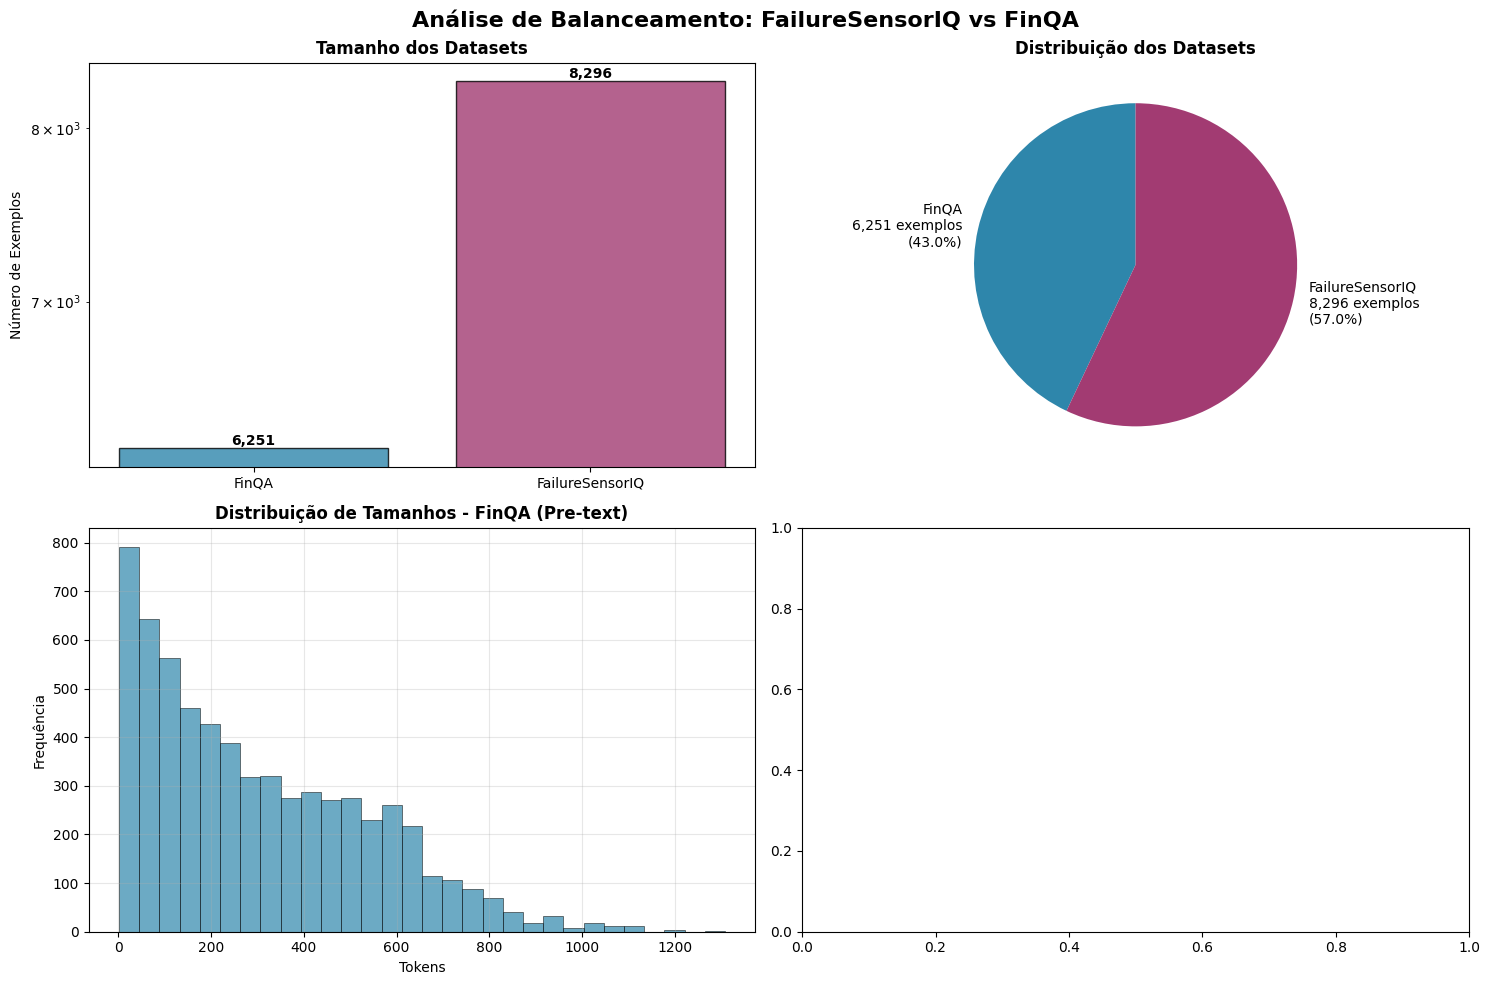


ESTATÍSTICAS DE BALANCEAMENTO:
Ratio FinQA/FailureSensorIQ: 0.75
FinQA representa 43.0% do dataset total
FailureSensorIQ representa 57.0% do dataset total
✅ BALANCEAMENTO ACEITÁVEL

Recomendações:
- Balanceamento adequado para fine-tuning


In [10]:
# Visualizações de Balanceamento dos Dados

def criar_visualizacoes_balanceamento(dataset_finqa, dataset_failure):
    """
    Cria visualizações para análise de balanceamento dos datasets
    """
    print("VISUALIZAÇÕES DE BALANCEAMENTO DOS DADOS")
    print("=" * 50)

    # Configurar o layout dos gráficos
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Análise de Balanceamento: FailureSensorIQ vs FinQA', fontsize=16, fontweight='bold')

    # 1. Gráfico de Barras - Comparação de Tamanhos dos Datasets
    ax1 = axes[0, 0]
    datasets = ['FinQA', 'FailureSensorIQ']
    tamanhos = [len(dataset_finqa), len(dataset_failure)]
    cores = ['#2E86AB', '#A23B72']

    bars = ax1.bar(datasets, tamanhos, color=cores, alpha=0.8, edgecolor='black', linewidth=1)
    ax1.set_title('Tamanho dos Datasets', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Número de Exemplos')
    ax1.set_yscale('log')

    # Adicionar valores nas barras
    for bar, tamanho in zip(bars, tamanhos):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{tamanho:,}', ha='center', va='bottom', fontweight='bold')

    # 2. Gráfico de Pizza - Proporção dos Datasets
    ax2 = axes[0, 1]
    total = len(dataset_finqa) + len(dataset_failure)
    sizes = [len(dataset_finqa), len(dataset_failure)]
    labels = [f'FinQA\n{len(dataset_finqa):,} exemplos\n({len(dataset_finqa)/total*100:.1f}%)', 
              f'FailureSensorIQ\n{len(dataset_failure):,} exemplos\n({len(dataset_failure)/total*100:.1f}%)']

    wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=cores, autopct='', 
                                       startangle=90, textprops={'fontsize': 10})
    ax2.set_title('Distribuição dos Datasets', fontweight='bold', fontsize=12)

    # 3. Histograma - Distribuição de Tamanhos (FinQA)
    ax3 = axes[1, 0]
    if not dataset_finqa.empty and 'tamanho_pre_text' in dataset_finqa.columns:
        ax3.hist(dataset_finqa['tamanho_pre_text'], bins=30, alpha=0.7, color='#2E86AB', 
                 edgecolor='black', linewidth=0.5)
        ax3.set_title('Distribuição de Tamanhos - FinQA (Pre-text)', fontweight='bold', fontsize=12)
        ax3.set_xlabel('Tokens')
        ax3.set_ylabel('Frequência')
        ax3.grid(True, alpha=0.3)

    # 4. Histograma - Distribuição de Tamanhos (FailureSensorIQ)
    ax4 = axes[1, 1]
    if not dataset_failure.empty and 'tamanho_pergunta' in dataset_failure.columns:
        ax4.hist(dataset_failure['tamanho_pergunta'], bins=15, alpha=0.7, color='#A23B72', 
                 edgecolor='black', linewidth=0.5)
        ax4.set_title('Distribuição de Tamanhos - FailureSensorIQ (Perguntas)', fontweight='bold', fontsize=12)
        ax4.set_xlabel('Tokens')
        ax4.set_ylabel('Frequência')
        ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Estatísticas de Balanceamento
    print("\nESTATÍSTICAS DE BALANCEAMENTO:")
    print("=" * 40)

    if not dataset_finqa.empty and not dataset_failure.empty:
        ratio = len(dataset_finqa) / len(dataset_failure)
        print(f"Ratio FinQA/FailureSensorIQ: {ratio:.2f}")
        print(f"FinQA representa {len(dataset_finqa)/total*100:.1f}% do dataset total")
        print(f"FailureSensorIQ representa {len(dataset_failure)/total*100:.1f}% do dataset total")
        
        if ratio > 10:
            print("⚠️  DESBALANCEAMENTO EXTREMO: FinQA é mais de 10x maior que FailureSensorIQ")
        elif ratio > 2:
            print("⚠️  DESBALANCEAMENTO SIGNIFICATIVO: FinQA é mais de 2x maior que FailureSensorIQ")
        else:
            print("✅ BALANCEAMENTO ACEITÁVEL")
        
        print(f"\nRecomendações:")
        if ratio > 10:
            print("- Considerar amostragem do FinQA para equilibrar")
            print("- Usar técnicas de data augmentation no FailureSensorIQ")
            print("- Implementar class weights no treinamento")
        elif ratio > 2:
            print("- Considerar amostragem estratificada")
            print("- Usar técnicas de balanceamento no treinamento")
        else:
            print("- Balanceamento adequado para fine-tuning")


criar_visualizacoes_balanceamento(dataset_finqa, dataset_failure)


## 8. Resumo Executivo


In [12]:
print("RESUMO EXECUTIVO")
print("=" * 40)

if not dataset_finqa.empty:
    print(f"\nFinQA: {len(dataset_finqa)} exemplos")
    print(f"  - Domínio: Financeiro")
    print(f"  - Tipo: Raciocínio numérico")
    print(f"  - Complexidade: Alta (tabelas + programas)")
    
    # Calcular tamanho médio se as colunas existirem
    tamanho_medio_finqa = 0
    if 'tamanho_pergunta' in dataset_finqa.columns:
        tamanho_medio_finqa += dataset_finqa['tamanho_pergunta'].mean()
    if 'tamanho_resposta' in dataset_finqa.columns:
        tamanho_medio_finqa += dataset_finqa['tamanho_resposta'].mean()
    
    if tamanho_medio_finqa > 0:
        print(f"  - Tamanho médio: {tamanho_medio_finqa:.0f} tokens")
    else:
        print("  - Tamanho médio: Não calculável (colunas não disponíveis)")

if not dataset_failure.empty:
    print(f"\nFailureSensorIQ: {len(dataset_failure)} exemplos")
    print(f"  - Domínio: Industrial")
    print(f"  - Tipo: Múltipla escolha")
    print(f"  - Complexidade: Média (opções categóricas)")
    
    # Calcular tamanho médio se as colunas existirem
    tamanho_medio_failure = 0
    if 'tamanho_pergunta' in dataset_failure.columns:
        tamanho_medio_failure += dataset_failure['tamanho_pergunta'].mean()
    if 'tamanho_opcoes' in dataset_failure.columns:
        tamanho_medio_failure += dataset_failure['tamanho_opcoes'].mean()
    
    if tamanho_medio_failure > 0:
        print(f"  - Tamanho médio: {tamanho_medio_failure:.0f} tokens")
    else:
        print("  - Tamanho médio: Não calculável (colunas não disponíveis)")


RESUMO EXECUTIVO

FinQA: 6251 exemplos
  - Domínio: Financeiro
  - Tipo: Raciocínio numérico
  - Complexidade: Alta (tabelas + programas)
  - Tamanho médio: Não calculável (colunas não disponíveis)

FailureSensorIQ: 8296 exemplos
  - Domínio: Industrial
  - Tipo: Múltipla escolha
  - Complexidade: Média (opções categóricas)
  - Tamanho médio: Não calculável (colunas não disponíveis)
